In [7]:
import numpy as np
import qutip as qt
import matplotlib.pyplot as plt
from quantumScarFunctions import *

In [8]:
wd = 0.6366896896896898
t_max = 200
tlist = np.linspace(0, t_max, 400)
dis = 0.3
reals = 500
wm = 1.0

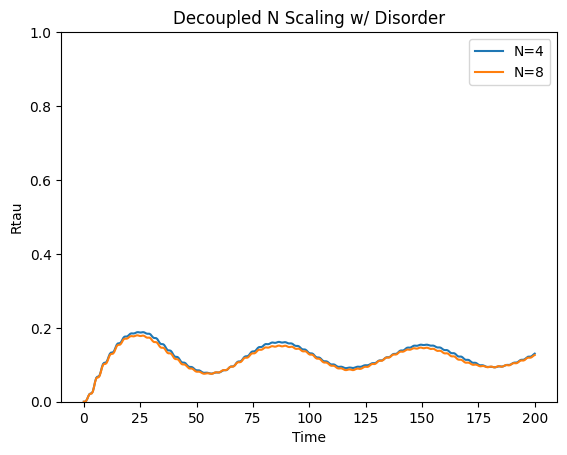

In [9]:
dz = 0.0
dy = 0.0
dx = dis

qargs = {"A": 0.1, "omega": wm}

for N in [4, 8]:
    full_qubit = 0
    xfull_qubit = 0

    for _ in range(reals):
        qH0_list, qH1_list, _ = get_qubit_ham(N, wm=wm, ham_disorder=[dz, dy, dx])

        dE_tot = 0
        bw_tot = 0
        for qH0, qH1 in zip(qH0_list, qH1_list):
            qeigenvalues, qeigenstates = qH0.eigenstates()
            bw_tot += qeigenvalues[-1] - qeigenvalues[0]

            qH = qt.QobjEvo([qH0, [qH1, coeff]], args=qargs)
            qpsi_t = qt.sesolve(qH, qeigenstates[0], tlist, e_ops=[qH0])
            dE_tot = dE_tot + np.real(qpsi_t.expect[0] - qpsi_t.expect[0][0])

        full_qubit += dE_tot / bw_tot

    xfull_qubit = full_qubit / reals
    plt.plot(tlist, xfull_qubit, label=f"N={N}")

plt.title(f"Decoupled N Scaling w/ Disorder")
plt.xlabel("Time")
plt.ylabel("Rtau")
plt.legend()
plt.ylim(0, 1)
plt.show()